# Entraînement et Comparaison de Modèles ML pour la Prédiction de Churn

Ce notebook entraîne et compare 3 algorithmes de classification :
1. **Régression Logistique**
2. **Random Forest Classifier**
3. **XGBoost**

## Objectif
Déterminer le meilleur modèle pour prédire le churn client en utilisant des métriques adaptées aux datasets déséquilibrés.

In [4]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score
)

# XGBoost
import xgboost as xgb

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


## 1. Chargement des Données

In [5]:
# Charger le dataset préparé pour le ML
DATA_PATH = Path(r"../data/processed/telco_customer_churn_ml_ready.csv")
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("CHARGEMENT DES DONNÉES")
print("=" * 80)
print(f"\nDimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nPremières lignes:")
display(df.head())

print(f"\nDistribution de la variable cible (Churn):")
print(df['Churn'].value_counts())
print(f"\nProportion:")
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

CHARGEMENT DES DONNÉES

Dimensions: 7043 lignes × 31 colonnes

Premières lignes:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0



Distribution de la variable cible (Churn):
Churn
0    5174
1    1869
Name: count, dtype: int64

Proportion:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## 2. Préparation des Données pour l'Entraînement

In [6]:
# Séparer les features (X) et la target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print("=" * 80)
print("PRÉPARATION DES DONNÉES")
print("=" * 80)
print(f"\nNombre de features: {X.shape[1]}")
print(f"Nombre d'observations: {X.shape[0]}")
print(f"\nVariables d'entrée (X): {list(X.columns)}")
print(f"\nVariable cible (y): Churn")
print(f"  - Classe 0 (No Churn): {(y == 0).sum()} clients ({(y == 0).sum() / len(y) * 100:.2f}%)")
print(f"  - Classe 1 (Churn): {(y == 1).sum()} clients ({(y == 1).sum() / len(y) * 100:.2f}%)")

PRÉPARATION DES DONNÉES

Nombre de features: 30
Nombre d'observations: 7043

Variables d'entrée (X): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Variable cible (y): Churn
  - Classe 0 (No Churn): 5174 clients (73.46%)
  - Classe 1 (Churn): 1869 clients (26.54%)


In [7]:
# Split Train/Test (80/20) avec stratification pour préserver la proportion de churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Important pour garder le même ratio de churn
)

print("\n" + "=" * 80)
print("SPLIT TRAIN / TEST")
print("=" * 80)
print(f"\nTrain set: {X_train.shape[0]} observations ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} observations ({X_test.shape[0] / len(X) * 100:.1f}%)")
print(f"\nDistribution du Churn dans Train: {y_train.value_counts(normalize=True).round(4) * 100}")
print(f"\nDistribution du Churn dans Test:  {y_test.value_counts(normalize=True).round(4) * 100}")
print("\n✓ La stratification a bien préservé la proportion de churn")


SPLIT TRAIN / TEST

Train set: 5634 observations (80.0%)
Test set:  1409 observations (20.0%)

Distribution du Churn dans Train: Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Distribution du Churn dans Test:  Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

✓ La stratification a bien préservé la proportion de churn


## 3. Entraînement des Modèles

Nous allons entraîner 3 modèles avec `class_weight='balanced'` pour gérer le déséquilibre des classes.

### 3.1 Régression Logistique

In [8]:
print("=" * 80)
print("MODÈLE 1 : RÉGRESSION LOGISTIQUE")
print("=" * 80)

# Entraînement avec class_weight='balanced' pour gérer le déséquilibre
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

# Prédictions
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print("\n✓ Régression Logistique entraînée avec succès")

MODÈLE 1 : RÉGRESSION LOGISTIQUE

✓ Régression Logistique entraînée avec succès


### 3.2 Random Forest Classifier

In [9]:
print("=" * 80)
print("MODÈLE 2 : RANDOM FOREST CLASSIFIER")
print("=" * 80)

# Entraînement
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1  # Utilise tous les CPU disponibles
)

rf_clf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("\n✓ Random Forest entraîné avec succès")

MODÈLE 2 : RANDOM FOREST CLASSIFIER

✓ Random Forest entraîné avec succès


### 3.3 XGBoost

In [10]:
print("=" * 80)
print("MODÈLE 3 : XGBOOST")
print("=" * 80)

# Calculer le ratio pour scale_pos_weight (gestion du déséquilibre)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale pos weight: {scale_pos_weight:.2f}")

# Entraînement
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Pour gérer le déséquilibre
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("\n✓ XGBoost entraîné avec succès")

MODÈLE 3 : XGBOOST

Scale pos weight: 2.77

✓ XGBoost entraîné avec succès


## 4. Évaluation des Modèles

Pour un dataset déséquilibré, nous utilisons plusieurs métriques :

### 4.1 Fonction d'Évaluation Complète

In [11]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """
    Évalue un modèle avec toutes les métriques pertinentes
    """
    print("=" * 80)
    print(f"ÉVALUATION : {model_name.upper()}")
    print("=" * 80)
    
    # Métriques de base
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n📊 MÉTRIQUES GLOBALES")
    print(f"{'Accuracy:':<20} {accuracy:.4f} (⚠️  peut être trompeur avec déséquilibre)")
    print(f"{'ROC-AUC Score:':<20} {roc_auc:.4f}")
    print(f"\n📊 MÉTRIQUES POUR LE CHURN (Classe 1)")
    print(f"{'Precision:':<20} {precision:.4f} (parmi les prédictions 'Churn', % de vrais churns)")
    print(f"{'Recall:':<20} {recall:.4f} (parmi les vrais churns, % détectés) ⭐ IMPORTANT")
    print(f"{'F1-Score:':<20} {f1:.4f} (équilibre Precision/Recall)")
    
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n📊 MATRICE DE CONFUSION")
    print(f"{'':>15} Prédit No    Prédit Yes")
    print(f"{'Vrai No':<15} {cm[0,0]:<12} {cm[0,1]:<12} (Faux Positifs)")
    print(f"{'Vrai Yes':<15} {cm[1,0]:<12} {cm[1,1]:<12}")
    print(f"{'':>15} (Faux Négatifs) (Vrais Positifs)")
    
    # Rapport de classification détaillé
    print(f"\n📊 RAPPORT DÉTAILLÉ")
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

### 4.2 Évaluation Régression Logistique

In [12]:
results_log = evaluate_model(y_test, y_pred_log, y_proba_log, "Régression Logistique")

ÉVALUATION : RÉGRESSION LOGISTIQUE

📊 MÉTRIQUES GLOBALES
Accuracy:            0.7388 (⚠️  peut être trompeur avec déséquilibre)
ROC-AUC Score:       0.8418

📊 MÉTRIQUES POUR LE CHURN (Classe 1)
Precision:           0.5052 (parmi les prédictions 'Churn', % de vrais churns)
Recall:              0.7834 (parmi les vrais churns, % détectés) ⭐ IMPORTANT
F1-Score:            0.6143 (équilibre Precision/Recall)

📊 MATRICE DE CONFUSION
                Prédit No    Prédit Yes
Vrai No         748          287          (Faux Positifs)
Vrai Yes        81           293         
                (Faux Négatifs) (Vrais Positifs)

📊 RAPPORT DÉTAILLÉ
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 4.3 Évaluation Random Forest

In [13]:
results_rf = evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")

ÉVALUATION : RANDOM FOREST

📊 MÉTRIQUES GLOBALES
Accuracy:            0.7637 (⚠️  peut être trompeur avec déséquilibre)
ROC-AUC Score:       0.8419

📊 MÉTRIQUES POUR LE CHURN (Classe 1)
Precision:           0.5403 (parmi les prédictions 'Churn', % de vrais churns)
Recall:              0.7353 (parmi les vrais churns, % détectés) ⭐ IMPORTANT
F1-Score:            0.6229 (équilibre Precision/Recall)

📊 MATRICE DE CONFUSION
                Prédit No    Prédit Yes
Vrai No         801          234          (Faux Positifs)
Vrai Yes        99           275         
                (Faux Négatifs) (Vrais Positifs)

📊 RAPPORT DÉTAILLÉ
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.76      0.77      1409



### 4.4 Évaluation XGBoost

In [14]:
results_xgb = evaluate_model(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

ÉVALUATION : XGBOOST

📊 MÉTRIQUES GLOBALES
Accuracy:            0.7580 (⚠️  peut être trompeur avec déséquilibre)
ROC-AUC Score:       0.8369

📊 MÉTRIQUES POUR LE CHURN (Classe 1)
Precision:           0.5306 (parmi les prédictions 'Churn', % de vrais churns)
Recall:              0.7647 (parmi les vrais churns, % détectés) ⭐ IMPORTANT
F1-Score:            0.6265 (équilibre Precision/Recall)

📊 MATRICE DE CONFUSION
                Prédit No    Prédit Yes
Vrai No         782          253          (Faux Positifs)
Vrai Yes        88           286         
                (Faux Négatifs) (Vrais Positifs)

📊 RAPPORT DÉTAILLÉ
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



## 5. Comparaison Visuelle des Modèles

### 5.1 Tableau Comparatif des Métriques

In [15]:
# Créer un DataFrame de comparaison
comparison_df = pd.DataFrame([
    results_log,
    results_rf,
    results_xgb
])

# Supprimer la colonne confusion_matrix pour l'affichage
comparison_display = comparison_df.drop(columns=['confusion_matrix']).round(4)

print("=" * 80)
print("COMPARAISON DES 3 MODÈLES")
print("=" * 80)
print("\n")
display(comparison_display)

# Identifier le meilleur modèle pour chaque métrique
print("\n🏆 MEILLEUR MODÈLE PAR MÉTRIQUE")
print("=" * 80)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    best_model = comparison_display.loc[comparison_display[metric].idxmax(), 'model']
    best_value = comparison_display[metric].max()
    print(f"{metric.upper():<15} : {best_model:<25} ({best_value:.4f})")

COMPARAISON DES 3 MODÈLES




,model,accuracy,precision,recall,f1,roc_auc
0,Régression Logistique,0.7388,0.5052,0.7834,0.6143,0.8418
1,Random Forest,0.7637,0.5403,0.7353,0.6229,0.8419
2,XGBoost,0.7580,0.5306,0.7647,0.6265,0.8369



🏆 MEILLEUR MODÈLE PAR MÉTRIQUE
ACCURACY        : Random Forest             (0.7637)
PRECISION       : Random Forest             (0.5403)
RECALL          : Régression Logistique     (0.7834)
F1              : XGBoost                   (0.6265)
ROC_AUC         : Random Forest             (0.8419)


### 5.2 Visualisation des Métriques

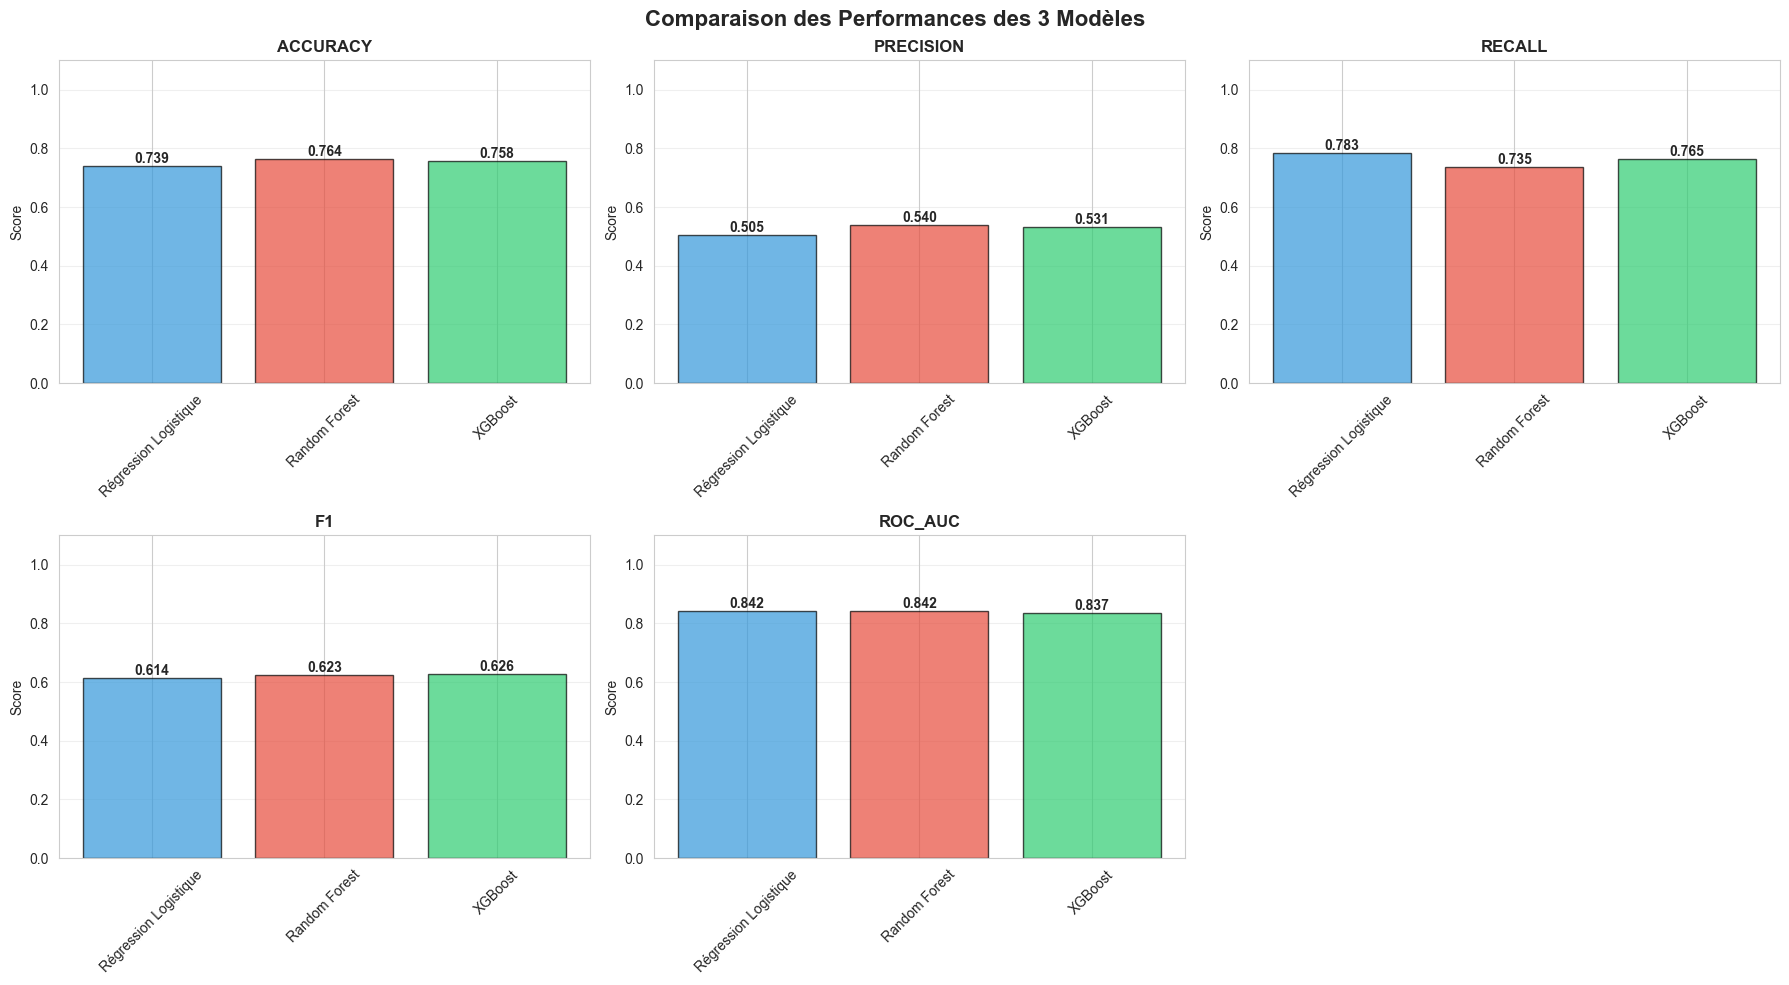

In [16]:
# Graphique de comparaison des métriques
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparaison des Performances des 3 Modèles', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = comparison_display[metric].values
    bars = ax.bar(comparison_display['model'], values, color=colors, alpha=0.7, edgecolor='black')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

# Supprimer le dernier subplot vide
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

### 5.3 Courbes ROC

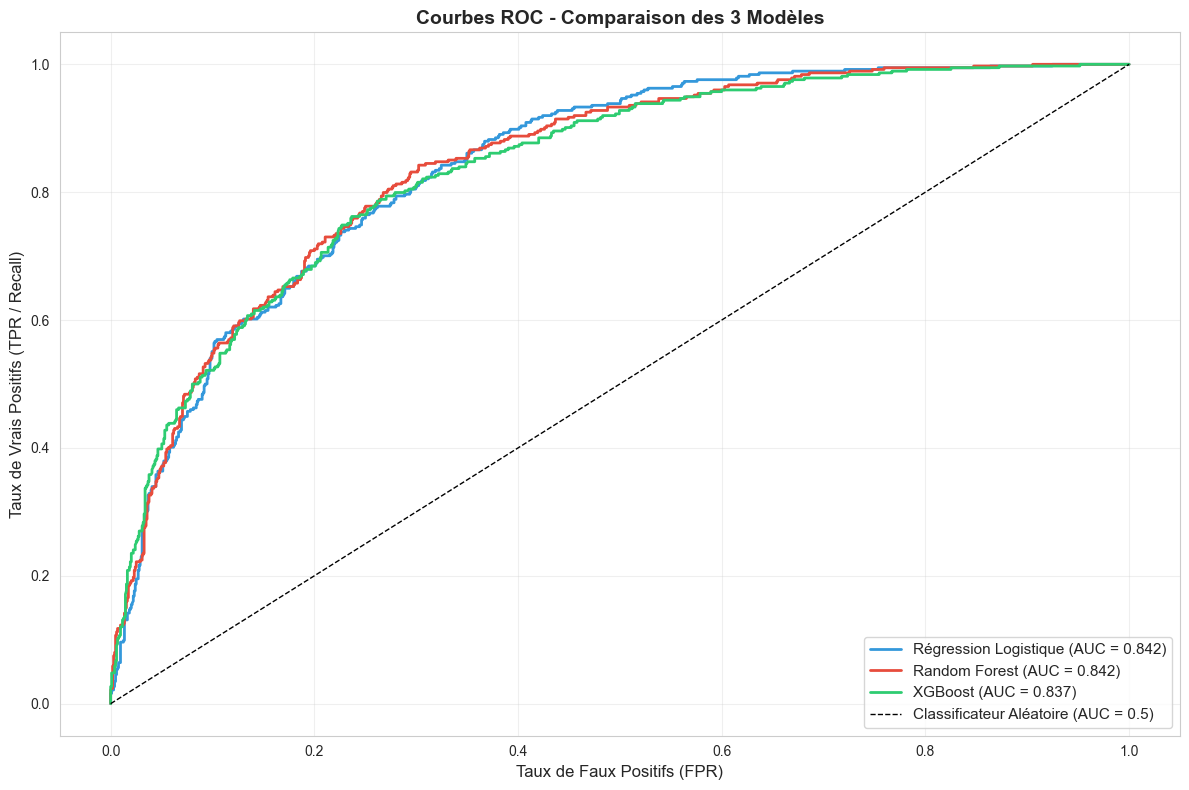

In [17]:
# Courbes ROC pour les 3 modèles
plt.figure(figsize=(12, 8))

# Régression Logistique
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
plt.plot(fpr_log, tpr_log, label=f'Régression Logistique (AUC = {results_log["roc_auc"]:.3f})', 
         linewidth=2, color='#3498db')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {results_rf["roc_auc"]:.3f})', 
         linewidth=2, color='#e74c3c')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {results_xgb["roc_auc"]:.3f})', 
         linewidth=2, color='#2ecc71')

# Ligne de référence (classificateur aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Classificateur Aléatoire (AUC = 0.5)', linewidth=1)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
plt.title('Courbes ROC - Comparaison des 3 Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Matrices de Confusion Comparées

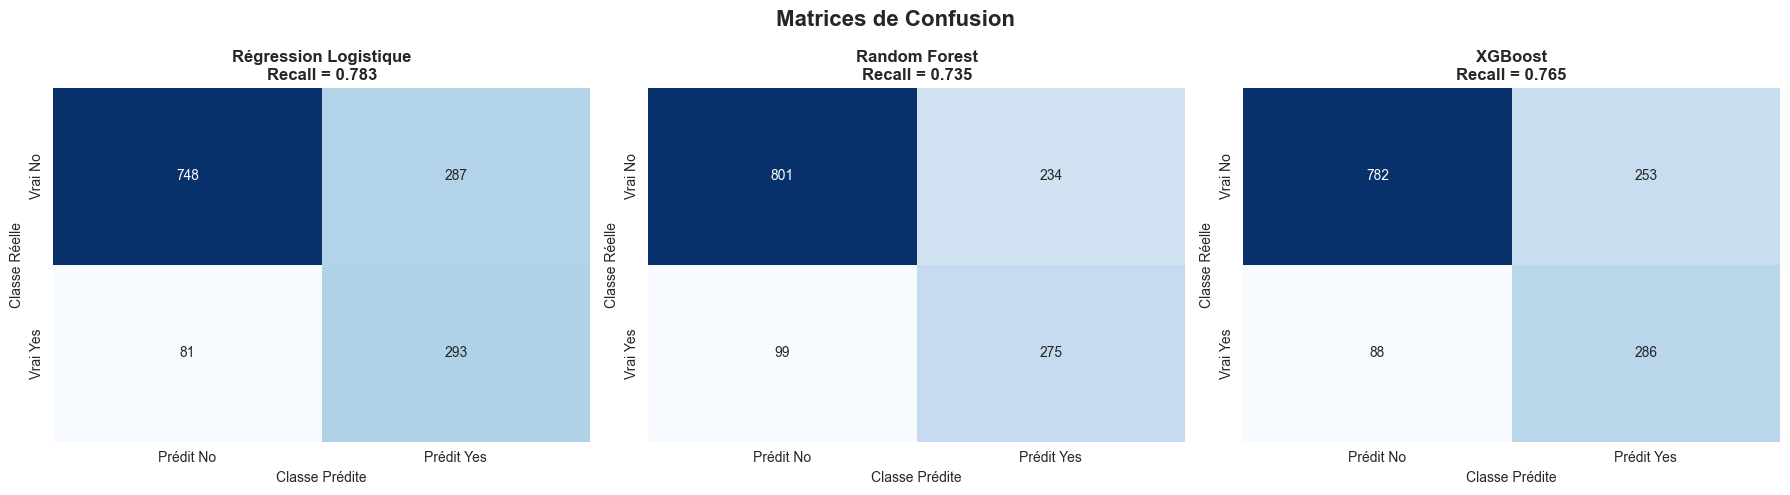

In [18]:
# Visualisation des matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion', fontsize=16, fontweight='bold')

models_results = [
    (results_log, 'Régression Logistique'),
    (results_rf, 'Random Forest'),
    (results_xgb, 'XGBoost')
]

for idx, (result, title) in enumerate(models_results):
    cm = result['confusion_matrix']
    
    # Créer un heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Prédit No', 'Prédit Yes'],
                yticklabels=['Vrai No', 'Vrai Yes'],
                cbar=False)
    
    axes[idx].set_title(f'{title}\nRecall = {result["recall"]:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Classe Réelle')
    axes[idx].set_xlabel('Classe Prédite')

plt.tight_layout()
plt.show()

### 5.5 Feature Importance (Random Forest & XGBoost)

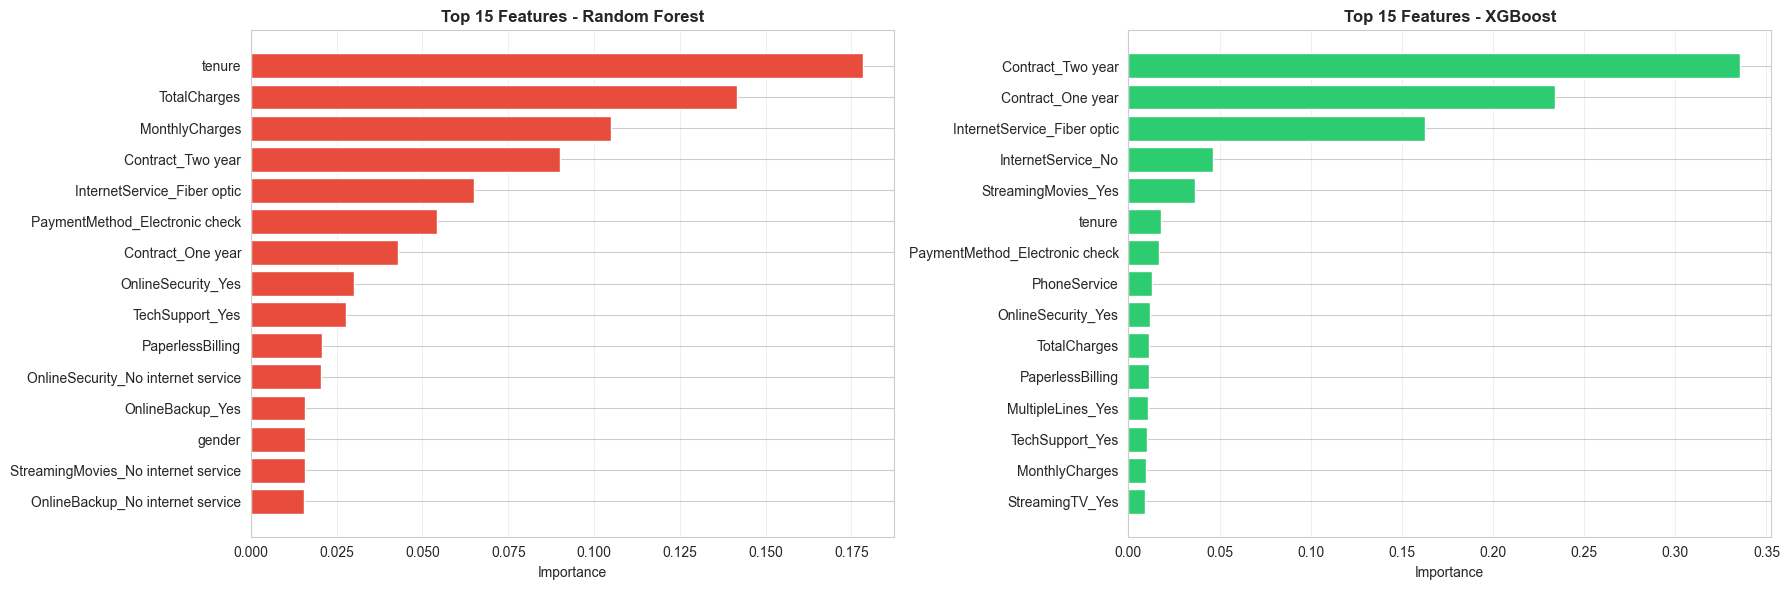


📊 TOP 10 FEATURES PAR MODÈLE

Random Forest:
                       feature  importance
                        tenure    0.178385
                  TotalCharges    0.141786
                MonthlyCharges    0.104999
             Contract_Two year    0.090219
   InternetService_Fiber optic    0.065045
PaymentMethod_Electronic check    0.054119
             Contract_One year    0.042973
            OnlineSecurity_Yes    0.029969
               TechSupport_Yes    0.027690
              PaperlessBilling    0.020638

XGBoost:
                       feature  importance
             Contract_Two year    0.335761
             Contract_One year    0.234054
   InternetService_Fiber optic    0.162653
            InternetService_No    0.046482
           StreamingMovies_Yes    0.036580
                        tenure    0.017807
PaymentMethod_Electronic check    0.016705
                  PhoneService    0.013115
            OnlineSecurity_Yes    0.011713
                  TotalCharges    0.01144

In [19]:
# Feature Importance pour Random Forest et XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='#e74c3c')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features - Random Forest', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# XGBoost
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(feature_importance_xgb['feature'], feature_importance_xgb['importance'], color='#2ecc71')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features - XGBoost', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 TOP 10 FEATURES PAR MODÈLE")
print("=" * 80)
print("\nRandom Forest:")
print(feature_importance_rf.head(10).to_string(index=False))
print("\nXGBoost:")
print(feature_importance_xgb.head(10).to_string(index=False))

## 6. Analyse et Recommandation

In [20]:
print("=" * 80)
print("📊 ANALYSE COMPARATIVE ET RECOMMANDATION")
print("=" * 80)

print("\n🎯 CONTEXTE : Prédiction de Churn")
print("-" * 80)
print("Pour le churn, le RECALL est la métrique la plus importante car :")
print("  ✓ Manquer un client à risque = Perte de revenu potentielle")
print("  ✓ Faux positif = Coût marketing limité")
print("  → Il vaut mieux contacter trop de clients que d'en manquer !")

print("\n📈 RÉSULTATS COMPARÉS")
print("-" * 80)
print(f"{'Modèle':<25} {'Recall':<10} {'Precision':<12} {'F1-Score':<12} {'ROC-AUC':<10}")
print("-" * 80)
for _, row in comparison_display.iterrows():
    print(f"{row['model']:<25} {row['recall']:<10.4f} {row['precision']:<12.4f} {row['f1']:<12.4f} {row['roc_auc']:<10.4f}")

# Identifier le meilleur modèle selon le recall
best_recall_idx = comparison_display['recall'].idxmax()
best_model = comparison_display.loc[best_recall_idx]

print("\n" + "=" * 80)
print("🏆 RECOMMANDATION FINALE")
print("=" * 80)
print(f"\nModèle recommandé : {best_model['model'].upper()}")
print("\nJustification :")
print(f"  ✓ Meilleur Recall: {best_model['recall']:.4f} - Détecte {best_model['recall']*100:.2f}% des churns")
print(f"  ✓ F1-Score: {best_model['f1']:.4f} - Bon équilibre global")
print(f"  ✓ ROC-AUC: {best_model['roc_auc']:.4f} - Bonne capacité de discrimination")

print("\n💡 POINTS D'AMÉLIORATION POSSIBLES")
print("-" * 80)
print("  1. Tuning des hyperparamètres (GridSearch / RandomSearch)")
print("  2. Feature Engineering (créer de nouvelles variables)")
print("  3. Ajuster le seuil de classification pour maximiser Recall")
print("  4. Essayer des techniques d'ensemble (Stacking, Voting)")
print("  5. Rééquilibrage des données (SMOTE, sous-échantillonnage)")

print("\n✅ PROCHAINES ÉTAPES")
print("-" * 80)
print(f"  1. Optimiser les hyperparamètres de {best_model['model']}")
print("  2. Valider les performances sur un ensemble de validation croisée")
print("  3. Analyser les erreurs (clients mal classés)")
print("  4. Déployer le modèle en production avec monitoring")
print("=" * 80)

📊 ANALYSE COMPARATIVE ET RECOMMANDATION

🎯 CONTEXTE : Prédiction de Churn
--------------------------------------------------------------------------------
Pour le churn, le RECALL est la métrique la plus importante car :
  ✓ Manquer un client à risque = Perte de revenu potentielle
  ✓ Faux positif = Coût marketing limité
  → Il vaut mieux contacter trop de clients que d'en manquer !

📈 RÉSULTATS COMPARÉS
--------------------------------------------------------------------------------
Modèle                    Recall     Precision    F1-Score     ROC-AUC   
--------------------------------------------------------------------------------
Régression Logistique     0.7834     0.5052       0.6143       0.8418    
Random Forest             0.7353     0.5403       0.6229       0.8419    
XGBoost                   0.7647     0.5306       0.6265       0.8369    

🏆 RECOMMANDATION FINALE

Modèle recommandé : RÉGRESSION LOGISTIQUE

Justification :
  ✓ Meilleur Recall: 0.7834 - Détecte 78.34% des 